# Learned controllers: what a battery gets from imitation and reinforcement

`CODE.ipynb` asks what a **forecast** buys a home battery, answered with rules and
with a receding-horizon MILP. This notebook adds the third family — controllers
that **learn** the dispatch rather than being told it — and prices them through
exactly the same settlement:

| | what it is | what it needs at run time |
|---|---|---|
| **IL** `bc` | behaviour cloning of the whole-period MILP, solved over the *training* period | one forward pass |
| **RL** `dqn` | Double DQN, dueling head, rewarded by the arm's own settlement | one forward pass |
| **IL+RL** `bc_dqn` | the clone, then fine-tuned by the DQN under a BC regulariser | one forward pass |

All three are `Rule_Based_Control.Policy` subclasses, executed by `run_policy`
through the arm's `settle` with the endogenous SI contract converged — so a
learned row and a rule row differ **only** in how a setpoint is chosen.

### Train / validation / test

Each household's model is trained on that household's own data only, in three
disjoint parts:

| part | days | used for |
|---|---|---|
| **train** | the two training years minus every 5th week (590 d) | RL episodes, the clone's fit |
| **validation** | those 20 held-out weeks (140 d, every calendar month) | early stopping, and every hyperparameter choice |
| **test** | the scored year (365 d) | one `run_policy` evaluation at the very end |

The teacher MILP demonstrates over both training years and never sees the test
year. An earlier version trained on year 2 alone, validated on its last 60 days
(so never trained on May–June), and had its RL knobs picked from scored-year
costs on one household; every number below replaces it.

### How the battery is priced

As a **net present value at 5 %** over the pack's life, which ends at whichever
comes first: the 12-year calendar life or 6000 equivalent full cycles. The pack
(250 EUR/kWh + 1000 EUR install, converted to AUD on AU) is paid for once, as
that capex; a cycle costs money only by ending the pack early. No controller in
this study gets there — the hardest cycler does ~273 EFC/a, 22 years of cycle
life — so every pack lives 12 years and **cycling is free on this axis**.
`hems_study.summarize` prices the rules, the MILP arms and the learned rows the
same way.

That replaced an accounting that charged every cycle 0.417 €/EFC *and* took the
full capex in the NPV, paying for the cells twice. **The controllers now optimise
the same thing**: the MILP family dispatches with no per-cycle wear term, and the
learned agents are trained without one (ALGO_VERSION 6), their early stopping and
tuning scored on the bill plus this lifetime wear. The old per-cycle price
survives only as the study's `*_wearprice` ablation and as the reported
`wear_shadow_eur` column.

### What the screen covers

1260 runs: 30 households × 2 tariffs × 7 observation contracts × 3 methods,
plus 52 re-trained at double budget. Produced by

```bash
python3 run_rl_benchmark.py --tune --ids <30 study units> --jobs 12   # validation only
python3 run_rl_benchmark.py --ids <30 study units> --methods dqn bc bc_dqn --jobs 12
python3 run_rl_benchmark.py --retrain-unconverged --steps 1000000 --jobs 12
```

Nothing here re-trains or re-solves. The ranking reads the study's own frame
with the two deployable learned controllers joined on by
`hems_study.merge_learned_controllers`; the ablations read
`results_local/rl_screen/`. A few seconds cold.

### The observation contracts (`variant`)

`nofc` no load/PV forecast at all · `fc_h6` / `fc_h12` / `fc_h24` a **causal**
trailing-median forecast with 6/12/24 h of lookahead · `loadfc_pvtruth_h24`
perfect roof on a real load model · `truth_h24` perfect everything ·
`fc_h24_noprice` (AU) blind to the price · `fc_h24_nopeak` (SI) blind to the
contract and the running peak. The last two are the **"what data does this
tariff actually need"** ablations. `truth_h24` is a diagnostic, exactly like
`price_oracle` — never a deployable claim.

> **On hyperparameters.** γ, the n-step window and the BC regulariser were chosen
> on the **validation weeks only** (`run_rl_benchmark.tune`, a small grid, 30
> households, test year never evaluated), scored on the bill plus lifetime wear —
> this notebook's own axis, except that on SI the validation rollouts do not
> re-agree the contract (§6). Everything else is a default. See §7.

In [1]:
import importlib, json
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

import hems_study as hs
import figure_style as fs
import run_rl_benchmark as rb
import Battery_Economics as be
import pv_split as ps
hs, fs, rb, ps = (importlib.reload(m) for m in (hs, fs, rb, ps))

import Plotting_Functions as pf
pf = importlib.reload(pf)
pf.use(subdir="hems", titles=False)
from Plotting_Functions import INK, INK_2, MUTED, SURFACE, SERIES, EUR, PLAIN, finish

# The deployable observation contract: a causal day-ahead forecast on both
# channels, 24 h of lookahead. `truth_h24` is a diagnostic -- like
# `price_oracle` -- and appears only where foresight IS the question.
DEPLOYABLE = "fc_h24"

# ---- (a) the study's own frame, with the learned controllers joined on ----
# This is the authoritative ranking: `summarize` prices every controller the
# same way and the learned rows go through it unchanged. The pack is priced
# ONCE, as an NPV at 5 % over min(12 y calendar, 6000 EFC): a cycle costs
# money only by ending the pack early, which no controller here does.
#
# The MILP family rides along from the reference arm: the full-year optimum
# (`milp_full`), the MPC with perfect foresight (`oracle`) and the MPC on
# Prophet (`prophet`). Prophet is not the best forecast the study has, so the
# MPC of the best DEPLOYABLE forecast arm is joined on as `mpc_best` -- a
# learned controller that only beats Prophet's MPC has beaten a straw man.
df_study = hs.collect_results()
MPC_BEST_ARM = {t: hs.best_mpc_arm(df_study, t) for t in hs.REFERENCE_ARM}
df_all = hs.merge_best_mpc(df_study, MPC_BEST_ARM)
df_all = hs.merge_learned_controllers(
    df_all[df_all.arm.isin(hs.REFERENCE_ARM.values())].reset_index(drop=True))
long = hs.summarize(df_all)
LABEL = {c: hs.controller_label(c, 48) for c in long.controller.unique()}


def labels_for(tariff):
    """`LABEL`, with `mpc_best` naming the forecaster it is on that tariff."""
    kind = hs.forecaster_kind_of(MPC_BEST_ARM[tariff])
    return {**LABEL, "mpc_best": f"MPC-MILP 24 h, {ps.forecast_label(kind)} "
                                 f"(best deployable)"}

# ---- (b) the RL screen, for the contracts the study frame does not carry ----
# Only `fc_h24` is joined above; the ablations live here. Put on the SAME
# accounting as `summarize`: the bill, plus the pack life the cycles use up
# (`hs.cycle_wear_eur` -- the one formula `summarize` charges), plus the
# standing charge on SI -- where it is NOT decision-independent, because the
# contract is endogenous and a peak shaver walks itself onto a cheaper one.
# Sign flipped so larger is better, like a saving. Every learned run lives the
# same 12 y, so a difference here is the NPV difference / PVF(12 y, 5 %).
rl = rb.load_results()
rl["wear_life"] = np.nan
for _t in ("AU", "SI"):
    _m = rl.tariff.eq(_t)
    rl.loc[_m, "wear_life"] = hs.cycle_wear_eur(rl.loc[_m, "efc"].to_numpy(), 10.0, _t)
rl["net"] = -(rl.cost_eur_closed + rl.wear_life
              + rl.fixed_eur.where(rl.tariff.eq("SI"), 0.0))
conv = rb._convergence_frame()

print(f"{len(rl)} learned runs | {rl.ident.nunique()} households | "
      f"pack priced as NPV at {be.DISCOUNT_RATE:.0%}, life = min("
      f"{be.BATTERY_CALENDAR_LIFE_Y} y, {be.BATTERY_CYCLE_LIMIT_EFC} EFC) | "
      f"runs whose cycles end the pack early: {int((rl.wear_life > 0).sum())}")
print("controllers on the study panel:", ", ".join(hs.controller_columns(df_all)))
print("best deployable MPC:", {t: hs.forecaster_kind_of(a)
                               for t, a in MPC_BEST_ARM.items()})

/Users/summerscholl/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  mpc_best: AU <- AU_H24_hbd_median14 (hbd_median14), 30 row(s)
  mpc_best: SI <- SI_H24_hbd_median14 (hbd_median14), 30 row(s)
  learned: bc_fc_h24          joined onto 60 row(s)
  learned: bc_dqn_fc_h24      joined onto 60 row(s)


1260 learned runs | 30 households | pack priced as NPV at 5%, life = min(12 y, 6000 EFC) | runs whose cycles end the pack early: 0
controllers on the study panel: no_battery, self_consumption, fixed_schedule, delayed_pv_charge, price_threshold, price_rank_daily, peak_shaving, self_consumption_peak_shaving, price_oracle, tariff_arbitrage, bc_dqn_fc_h24, bc_fc_h24, prophet, mpc_best, oracle, milp_full
best deployable MPC: {'AU': 'hbd_median14', 'SI': 'hbd_median14'}


## 1. Where the learned controllers land

Each row is one controller over the same 30 households; the dot cloud is the
households, the solid marker is the median, and the axis is the battery's
**lifetime NPV** (5 %, min(12 y, 6000 EFC), pack + install). Every value is
negative — at this quote no controller makes the pack pay for itself — so the
ranking is over how far short it falls. Drawn at the deployable contract `fc_h24`.

The MILP family is on the same axis: the full-year optimum, the 24 h MPC with
perfect foresight, the 24 h MPC on Prophet (the study's reference arm), and the
24 h MPC on the **best deployable forecast**, picked per tariff by
`hems_study.best_mpc_arm` as the deployable forecast arm with the best median
saving on the scored year (the setup cell prints which; the tick label names it). An ex-post best of ten favours
the MPC slightly, which is the conservative direction for a claim that a learner
beats it.

**AU.** The learned controllers clear every deployable MPC by a wide margin — the
fine-tuned clone's median NPV is −4206 AUD (253 AUD/a net saving), the clone's
−4334 (238), against −4843 (181) for the MPC on the best deployable forecast
(`hbd_median14`) and −5091 (153) on Prophet — at one forward pass per interval
instead of an LP solve. They do not reach the price rules (`price_rank_daily`
−4046, 271 AUD/a) or the full-year optimum (−3952, 282), which, dispatching
without a wear price, is the ceiling again.

**SI.** The clone lands mid-table: NPV −3553 EUR (47 EUR/a), ahead of
self-consumption (−3615, 40) and every deployable MPC (best: −3706, 29); the
fine-tune is just behind it (−3614, 40). The rule written for this tariff,
`self_consumption_peak_shaving`, reaches −3350 (69), the perfect-foresight MPC
−3331 (72) and the full-year MILP −3044 (104). SI's money is a monthly capacity charge;
neither copying a perfect-foresight plan nor reinforcing on the bill collects
the well-timed shave a month that earns it.
§6 takes the SI test year apart and shows why: the training reward never sees
the contract.


findfont: Failed to find font weight semibold, now using 700.


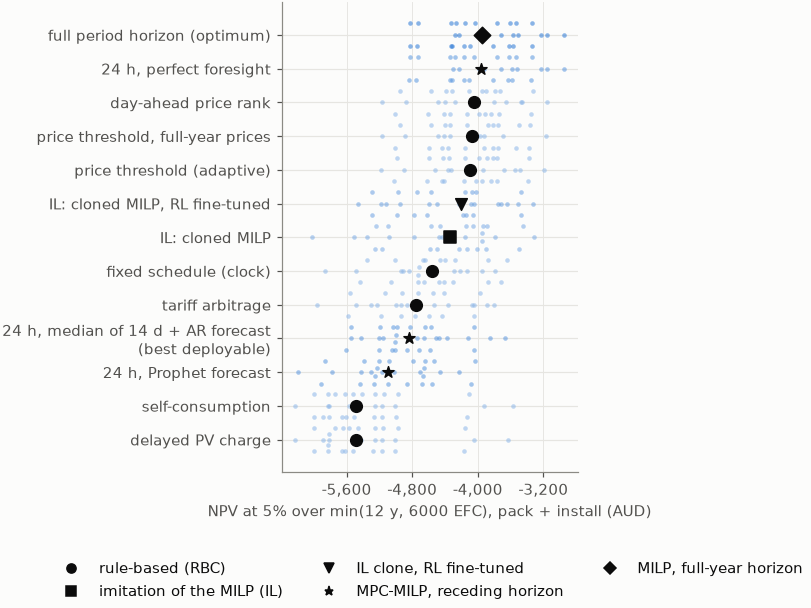

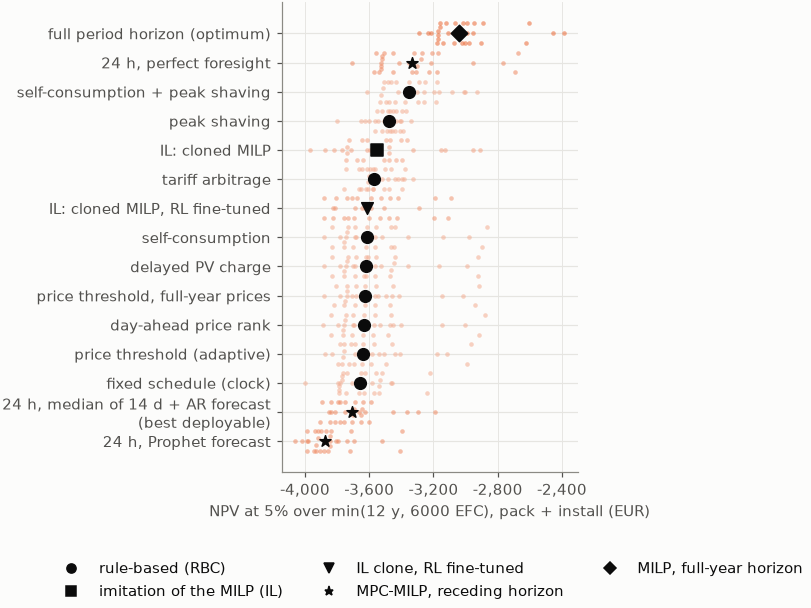

                         saving_operating  wear_shadow_eur  saving_annual_net     npv    efc  service_life_y
arm    controller                                                                                           
AU_H24 bc_dqn_fc_h24                235.1             81.1              235.1 -4364.2  194.6            12.0
       bc_fc_h24                    227.6             79.4              227.6 -4430.7  190.6            12.0
       milp_full                    283.9             98.4              283.9 -3931.3  236.1            12.0
       mpc_best                     187.3             97.5              187.3 -4787.6  233.9            12.0
       oracle                       283.1             98.5              283.1 -3938.4  236.3            12.0
       prophet                      161.0             99.7              161.0 -5020.6  239.3            12.0
       self_consumption             127.7             30.2              127.7 -5315.5   72.4            12.0
SI_H24 bc_dqn_fc_h2

In [2]:
# THE LIFETIME NPV, the comparison axis: one simulated year of operating
# saving (bill, plus on SI the contract the controller's own peaks agreed to)
# over the pack's life, min(12 y calendar, 6000 EFC), at 5 %, against the pack
# + install in the arm's own currency. Every controller is negative -- at this
# quote no pack pays for itself -- so the ranking is over how far short it
# falls. The per-cycle wear price is NOT in it: that is what the MILP and the
# learned agents dispatch against, not what the pack costs.
# One figure per tariff -- at \textwidth a shared row gives each ranking 3.5 in
# for eleven wrapped controller names.
for arm in hs.REFERENCE_ARM.values():
    tariff = hs.arm_tariff(arm)
    lab = labels_for(tariff)
    sub = long[(long.arm == arm) & (long.controller != "no_battery")]
    order = (sub.groupby("controller")["npv"].median()
             .sort_values().index.tolist())
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.80))
    for row, c in enumerate(order):
        v = sub.loc[sub.controller == c, "npv"].to_numpy()
        ax.scatter(v, row + fs.beeswarm(v), s=9, alpha=0.55, linewidths=0,
                   color=fs.ctrl_color(tariff, c), zorder=2)
        ax.scatter([np.median(v)], [row], marker=fs.ctrl_marker(c), s=58,
                   color=INK, zorder=3)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([fs.tick_label(c, lab) for c in order])
    # Five-digit tick labels at the default density run into each other.
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    fams = [f for f in ("reference", "RBC", "IL", "RL", "IL+RL", "MPC", "MILP")
            if any(fs.ctrl_family(c) == f for c in order)]
    pf.key_legend(ax, [Line2D([], [], marker=fs.FAMILY_MARKER[f], color=INK,
                              ls="none", ms=6, label=fs.FAMILY_LABEL[f])
                       for f in fams], where="below", ncol=3)
    finish(ax, title=f"{tariff}: lifetime NPV of the battery, 30 households",
           xlabel=f"NPV at {be.DISCOUNT_RATE:.0%} over min({be.BATTERY_CALENDAR_LIFE_Y} y, "
                  f"{be.BATTERY_CYCLE_LIMIT_EFC} EFC), pack + install "
                  f"({hs.money(tariff)})", ylabel="", xfmt=PLAIN)
    pf.show(fig, f"rl_ranking_{tariff.lower()}")

# The learned rows beside the MILP family they are measured against: the
# annual operating saving, the per-cycle price the dispatch carried (not
# billed), the annual net that the NPV is built from, and the NPV itself.
print(long[long.controller.isin(["self_consumption", "bc_fc_h24", "bc_dqn_fc_h24",
                                 "prophet", "mpc_best", "oracle", "milp_full"])]
      .groupby(["arm", "controller"])[["saving_operating", "wear_shadow_eur",
                                       "saving_annual_net", "npv", "efc",
                                       "service_life_y"]]
      .mean().round(1).to_string())


## 2. What each piece of information is worth

The question the study exists to ask, put to the learned controllers. Every row
is a **within-household** difference between two observation contracts — same
roof, same load, same contract, same battery, same settlement, same accounting
— so it prices the *information*, not the households carrying it. Every pack
here lives 12 years, so a difference in annual net saving is the NPV difference
divided by PVF(12 y, 5 %) = 8.86.
Wilcoxon through `hems_study.paired_comparison`, the same statistic the MILP
arms are scored by, then **Holm-corrected** over the six questions per method.

Filled marker = significant after correction. The ★ rows are the 24 h MPC asked
the same two foresight questions for scale: perfect foresight (`oracle`) and a
perfect roof (the best forecast's `*_pvtruth` twin arm), each against the best
deployable forecast, Holm over those two. The result:

- **Perfect foresight separates from zero** for RL on AU (+11.7 AUD/a, 26 of 30,
  p_holm 0.0002) and for both cloned methods on SI (+7.4 / +8.5 EUR/a, 27 of
  30, p_holm 0.0001). For the MPC it is worth far more (+94 AUD/a on AU, +38
  EUR/a on SI, 30 of 30): a learner extracts much less from foresight than an
  optimiser does.
- **A perfect roof** is worth +1.4 EUR/a to the SI clone (22 of 30, p_holm
  0.020), and +12 AUD/a / +9 EUR/a to the MPC (30 of 30).
- **An achievable day-ahead forecast** separates once: +16.9 AUD/a for the AU
  fine-tune over no forecast at all (21 of 30, p_holm 0.007).
- **AU's price features *hurt* plain RL** (−11.0 AUD/a against the price-blind
  variant, 7 of 30, p_holm 0.003): with them it learns worse, not better. Three
  of the four runs that never converged are on that price-blind variant, so read
  this with care.

The headline matches the forecast study from the other direction — Prophet
losing to seasonal-naive: *the forecast worth having is mostly the one you
cannot buy.*


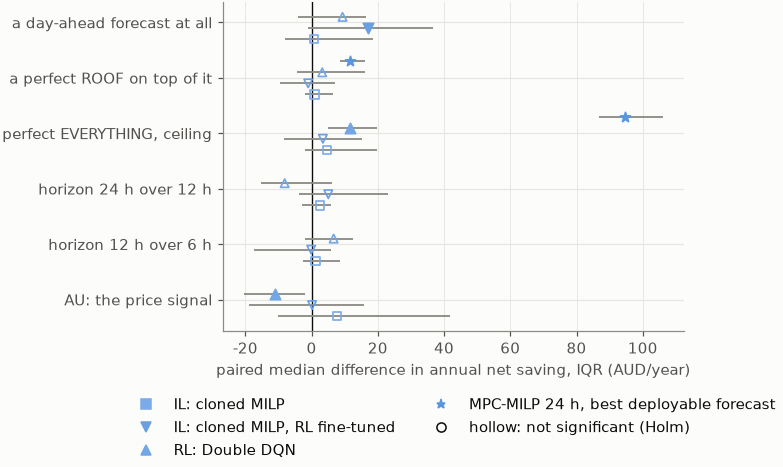

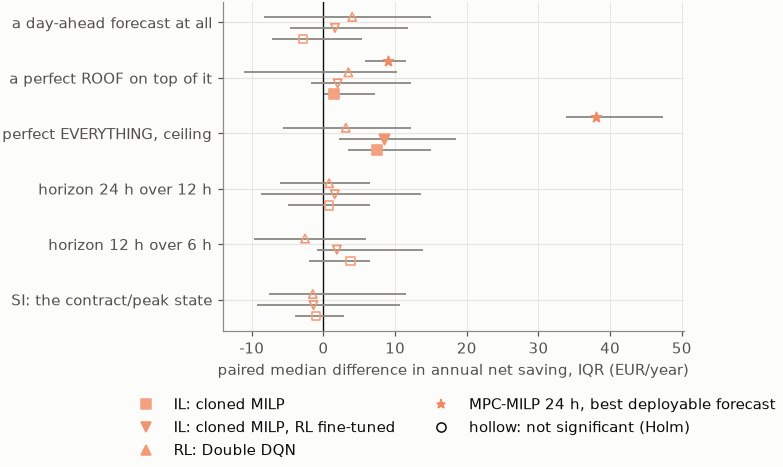


significant after Holm correction:
tariff   method                    question   median  wins  p_holm
    AU   bc_dqn a day-ahead forecast at all  16.9483    21  0.0074
    AU      dqn perfect EVERYTHING, ceiling  11.7114    26  0.0002
    AU      dqn        AU: the price signal -11.0179     7  0.0028
    AU mpc_best a perfect ROOF on top of it  11.7242    30  0.0000
    AU mpc_best perfect EVERYTHING, ceiling  94.4932    30  0.0000
    SI       bc a perfect ROOF on top of it   1.4094    22  0.0202
    SI       bc perfect EVERYTHING, ceiling   7.4204    27  0.0001
    SI   bc_dqn perfect EVERYTHING, ceiling   8.4514    27  0.0001
    SI mpc_best a perfect ROOF on top of it   9.0563    30  0.0000
    SI mpc_best perfect EVERYTHING, ceiling  37.9781    30  0.0000


In [3]:
# Each row is a WITHIN-household difference between two observation contracts:
# same roof, same load, same contract, same battery, same settlement, and the
# same accounting as the ranking above (annual net; every run here lives
# the same 12 y, so this IS the NPV difference over PVF(12 y, 5 %)). Holm over the six questions
# asked of each method -- at six tries an unadjusted 5 % manufactures a finding
# about a quarter of the time.
#
# The MPC is asked the two foresight questions it has arms for, for scale:
# perfect EVERYTHING is `oracle` against the best deployable forecast's MPC,
# and a perfect ROOF is that forecast's load model with the realised roof
# (its `*_pvtruth` twin arm) against the same. Read off `summarize`, the
# study's own axis, and paired by household like the learned rows.
METHOD_OFFSET = {"bc": +0.30, "bc_dqn": +0.10, "dqn": -0.10, "mpc_best": -0.30}
METHOD_LABEL = {**{m: hs.LEARNED_ALGORITHM[m][1] for m in ("bc", "bc_dqn", "dqn")},
                "mpc_best": "MPC-MILP 24 h, best deployable forecast"}


def mpc_voi_wide(tariff):
    """Per-household MPC net saving, columns named like the RL variants."""
    best = MPC_BEST_ARM[tariff]
    load = ps.load_kind(hs.forecaster_kind_of(best))
    twin = next((a for k, a in hs.forecast_arms(tariff).items()
                 if ps.channel_sources(k) == (load, "truth")), None)
    sources = {"truth_h24": (hs.REFERENCE_ARM[tariff], "oracle"),
               "fc_h24": (best, "prophet")}
    if twin is not None:
        sources["loadfc_pvtruth_h24"] = (twin, "prophet")
    arms = {a for a, _ in sources.values()}
    lg = hs.summarize(df_study[df_study.arm.isin(arms)])
    return pd.DataFrame({v: lg[(lg.arm == a) & (lg.controller == c)]
                            .set_index("dataset")["saving_annual_net"]
                         for v, (a, c) in sources.items()})


voi = []
for tariff in ("AU", "SI"):
    sub = rl[rl.tariff == tariff]
    qs = [q for q in rb.VOI_QUESTIONS
          if {q[1], q[2]} <= set(sub.variant.unique())]
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.62))
    for method in ("bc", "bc_dqn", "dqn", "mpc_best"):
        wide = (mpc_voi_wide(tariff) if method == "mpc_best" else
                sub[sub.method == method].pivot(index="ident", columns="variant",
                                                values="net"))
        # Holm over the questions THIS method is asked: six for a learner,
        # two for the MPC. Rows it has no arm for are simply not drawn.
        asked = [(row, q) for row, q in enumerate(qs)
                 if {q[1], q[2]} <= set(wide.columns)]
        stats = [hs.paired_comparison(wide, q[1], q[2]) for _, q in asked]
        adj = rb.holm([s["p_value"] for s in stats])
        for (row, q), s, a in zip(asked, stats, adj):
            y = row + METHOD_OFFSET[method]
            ax.plot([s["q1_diff"], s["q3_diff"]], [y, y], color=MUTED, lw=1.2,
                    zorder=2, solid_capstyle="butt")
            sig = a == a and a < 0.05
            ax.scatter([s["median_diff"]], [y], s=46 if sig else 30,
                       marker=fs.ctrl_marker(method),
                       color=fs.ctrl_color(tariff, method) if sig else "none",
                       edgecolors=fs.ctrl_color(tariff, method),
                       linewidths=1.1, zorder=3)
            voi.append({"tariff": tariff, "method": method,
                        "question": q[0].split("(")[0].strip(),
                        "median": s["median_diff"], "wins": s["n_a_greater"],
                        "p_holm": a})
    ax.axvline(0, color=INK, lw=0.9, zorder=1)
    ax.set_yticks(range(len(qs)))
    ax.set_yticklabels([q[0].split("(")[0].strip() for q in qs])
    ax.invert_yaxis()
    ax.grid(axis="x", color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    pf.key_legend(ax, [Line2D([], [], marker=fs.ctrl_marker(m),
        color=fs.ctrl_color(tariff, m), ls="none", ms=6, label=METHOD_LABEL[m])
        for m in METHOD_OFFSET]
        + [Line2D([], [], marker="o", mfc="none", mec=INK, color=INK, ls="none",
                  ms=6, label="hollow: not significant (Holm)")],
        where="below", ncol=2)
    finish(ax, title=f"{tariff}: what each piece of information is worth",
           xlabel=f"paired median difference in annual net saving, IQR "
                  f"({hs.money(tariff, 'year')})", ylabel="", xfmt=PLAIN)
    pf.show(fig, f"rl_value_of_information_{tariff.lower()}")

voi = pd.DataFrame(voi)
print("\nsignificant after Holm correction:")
print(voi[voi.p_holm < 0.05].round(4).to_string(index=False)
      if (voi.p_holm < 0.05).any() else "  (none)")

## 3. Imitation against reinforcement

**Cloning wins on SI and ties on AU**:

- **SI:** `bc` beats `dqn` on 27 of 30 households (median 17.7 EUR/a, p < 1e-4)
  and edges the fine-tune (2.3 EUR/a, 20 of 30, p = 0.04). The clone cycles
  125 EFC/a against the DQN's 88, and that cycling is what earns its energy line.
- **AU:** indistinguishable. `dqn` − `bc` median −15.2 AUD/a, 8 of 30, p = 0.31;
  `bc_dqn` − `bc` −0.4, p = 0.72.

With the per-cycle wear price out of the reward, the reinforced agents now cycle
like the clone (AU fine-tune 195 EFC/a against the clone's 191). On SI the gap
that is left is the contract, which neither method's reward sees (§6), and which
the clone inherits a little of from the MILP it copies.


  AU dqn     - bc: median   -15.2,  8/30 households, p=0.3085
  AU bc_dqn  - bc: median    -0.4, 15/30 households, p=0.7151


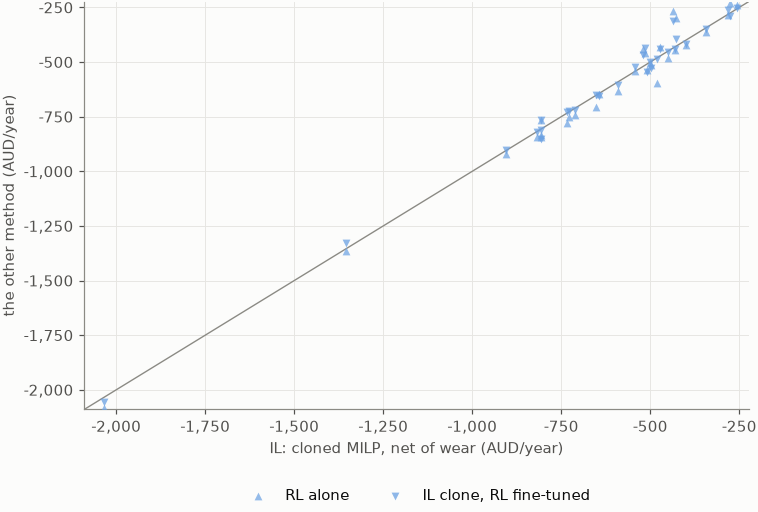

  SI dqn     - bc: median   -17.7,  3/30 households, p=0.0000
  SI bc_dqn  - bc: median    -2.3, 10/30 households, p=0.0405


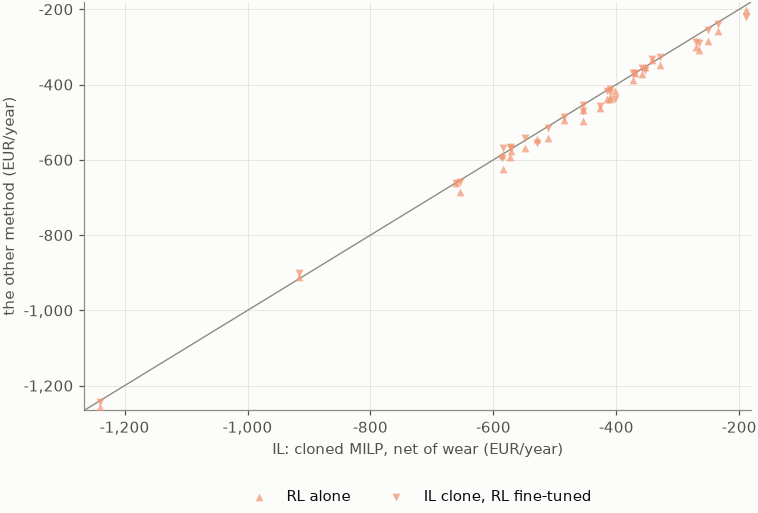

In [4]:
# Paired, on the y=x line, because the question is per household -- "was this
# household better cloned or reinforced?" -- not which mean is larger.
#
# Drawn on the annual net saving, the accounting `summarize` uses: the pack
# priced through its life, so a cycle is free until it ends the pack early. On
# SI the clone wins on 27 of 30; on AU the two tie. Reinforcement's timidity on the energy bill is, in part,
# wear avoidance that the bill alone does not credit it for -- which is the
# whole reason this figure is drawn on the net axis.
for tariff in ("AU", "SI"):
    wide = (rl[(rl.tariff == tariff) & (rl.variant == DEPLOYABLE)]
            .pivot(index="ident", columns="method", values="net"))
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.68))
    lim = [wide.min().min() - 8, wide.max().max() + 8]
    ax.plot(lim, lim, color=MUTED, lw=0.9, zorder=1)
    for other, marker, lab in (("dqn", "^", "RL alone"),
                               ("bc_dqn", "v", "IL clone, RL fine-tuned")):
        ax.scatter(wide["bc"], wide[other], s=26, marker=marker, alpha=0.75,
                   linewidths=0, color=fs.ctrl_color(tariff, other), zorder=3,
                   label=lab)
        r = hs.paired_comparison(wide, other, "bc")
        print(f"  {tariff} {other:7s} - bc: median {r['median_diff']:+7.1f}, "
              f"{r['n_a_greater']:2d}/{r['n']} households, p={r['p_value']:.4f}")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.grid(color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    pf.key_legend(ax, ax.get_legend_handles_labels()[0], where="below", ncol=2)
    finish(ax, title=f"{tariff}: imitation against reinforcement, net of wear",
           xlabel=f"IL: cloned MILP, net of wear ({hs.money(tariff, 'year')})",
           ylabel=f"the other method ({hs.money(tariff, 'year')})",
           xfmt=PLAIN, yfmt=PLAIN)
    pf.show(fig, f"rl_imitation_vs_reinforcement_{tariff.lower()}")

## 4. Did the training actually settle?

A saving from a model still improving when the budget ran out is a floor, not a
measurement, so this is checked rather than asserted. Each thin line is one
household's **best-so-far** validation cost, normalised to its own range — raw
EUR would stack thirty curves at thirty heights and show the spread of the
sample instead of the shape of the learning.

**836 of 840 runs met the early-stop rule.** 52 had *not* settled at 500k steps
and were re-trained at 1M; four AU runs still had not (three of them the
price-blind `fc_h24_noprice` fine-tune), and they are reported as they stand
rather than trained until they agree. The share of total improvement arriving in
the final quarter is ≈0 almost everywhere. The 500k results were overwritten by
the re-training, so the budget's effect was not re-measured on this split; on the
earliest split it was nil (median −1.2 EUR/a, p = 0.26).


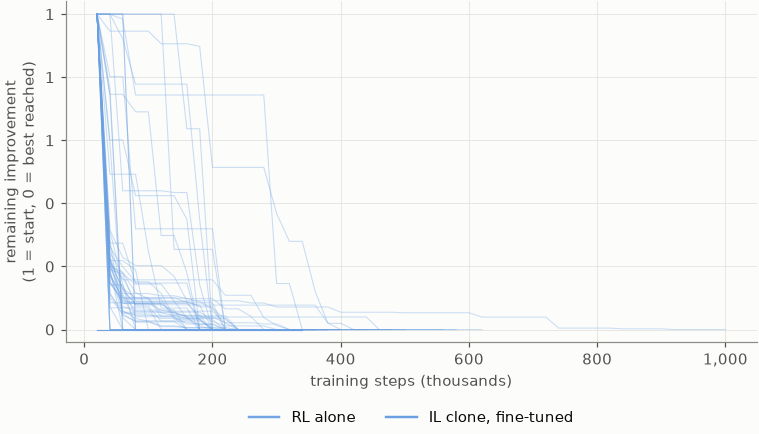

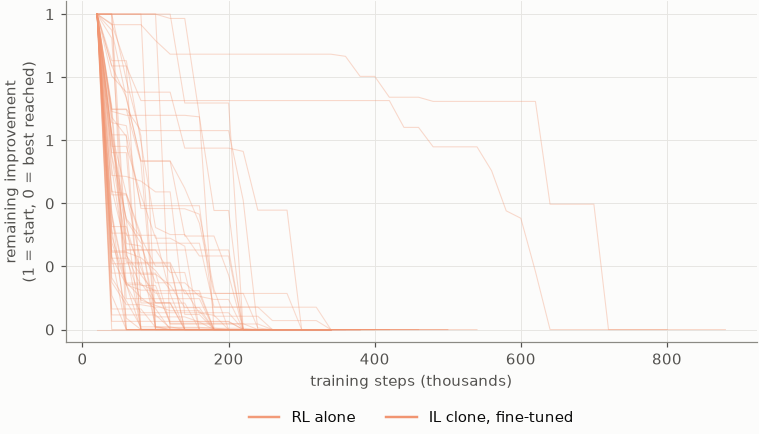


converged by the early-stop rule: 836/840
share of improvement in the final quarter, by tariff and method:
                 mean  median     max
tariff method                        
AU     bc_dqn  0.0066     0.0  0.5010
       dqn     0.0005     0.0  0.0347
SI     bc_dqn  0.0102     0.0  0.6408
       dqn     0.0000     0.0  0.0000


In [5]:
def val_traces(tariff, variant, method):
    """(steps, validation cost) for every household's training run."""
    d = Path("rl_models") / tariff / f"{variant}__{method}"
    out = []
    for f in sorted(d.glob("*.pt.history.json")):
        h = json.load(open(f)).get("dqn")
        if h and h.get("val_step"):
            out.append((np.asarray(h["val_step"]),
                        np.asarray(h["val_cost_closed"], dtype=float)))
    return out

# Drawn as the RUNNING BEST: the raw validation cost is noisy between
# evaluations, and what the early stop acts on -- and what the kept weights
# are -- is the best so far, not the last.
for tariff in ("AU", "SI"):
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.58))
    for method, lab in (("dqn", "RL alone"), ("bc_dqn", "IL clone, fine-tuned")):
        col = fs.ctrl_color(tariff, method)
        for steps, v in val_traces(tariff, DEPLOYABLE, method):
            best = np.minimum.accumulate(v)
            # Each household on its own scale: the bills differ two-fold, so
            # raw EUR would stack thirty curves at thirty heights and show the
            # spread of the sample instead of the shape of the learning.
            span = best[0] - best[-1]
            ax.plot(steps / 1000.0, (best - best[-1]) / span if span > 1e-9
                    else np.zeros_like(best), color=col, lw=0.7, alpha=0.35,
                    zorder=2)
        ax.plot([], [], color=col, lw=1.6, label=lab)
    ax.set_ylim(-0.04, 1.04)
    ax.grid(color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    pf.key_legend(ax, ax.get_legend_handles_labels()[0], where="below", ncol=2)
    finish(ax, title=f"{tariff}: every training run, best-so-far validation",
           xlabel="training steps (thousands)",
           ylabel="remaining improvement\n(1 = start, 0 = best reached)",
           yfmt=PLAIN, xfmt=PLAIN)
    pf.show(fig, f"rl_convergence_{tariff.lower()}")

learned_conv = conv[conv.method.isin(["dqn", "bc_dqn"])]
print(f"\nconverged by the early-stop rule: "
      f"{int(learned_conv.converged.fillna(False).astype(bool).sum())}"
      f"/{len(learned_conv)}")
print("share of improvement in the final quarter, by tariff and method:")
print(learned_conv.groupby(["tariff", "method"])["improvement_tail"]
      .agg(["mean", "median", "max"]).round(4).to_string())

## 5. Copying the optimum better is not the same as saving more

The clone is scored on two different things and they are not the same thing: how
often it picks the MILP's action, and what its own year saves. A
reactive map cannot express a plan, so the two come apart — which is why
held-out agreement is a training diagnostic and never the objective.

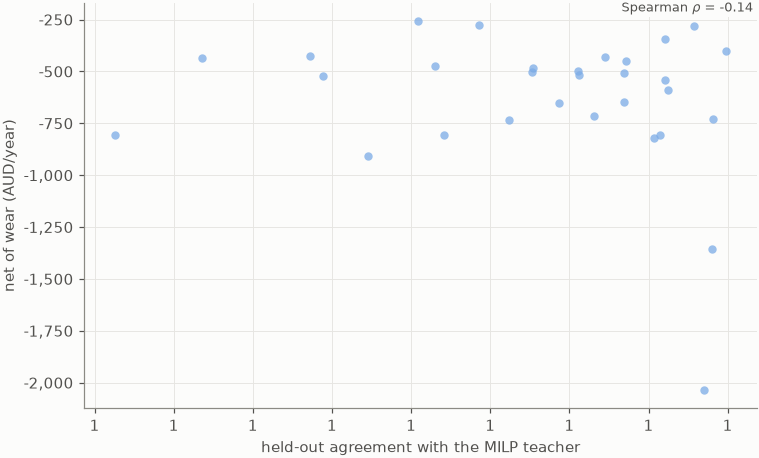

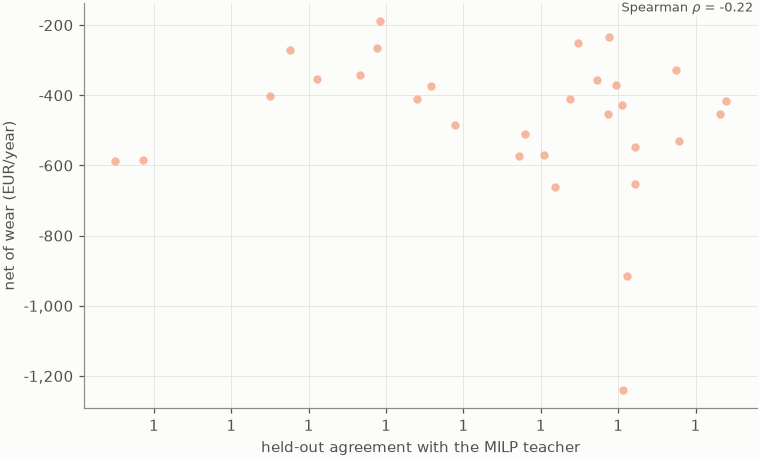

In [6]:
# The clone is scored on two different things, and they are not the same
# thing: how often it picks the MILP's action, and what its own year costs. A
# reactive map cannot express a plan, so the two come apart -- which is why
# agreement is a training diagnostic and never the objective.
agree = (conv[conv.method == "bc"][["tariff", "variant", "ident", "bc_agreement"]]
         .merge(rl[rl.method == "bc"][["tariff", "variant", "ident", "net"]],
                on=["tariff", "variant", "ident"]))
for tariff in ("AU", "SI"):
    a = agree[(agree.tariff == tariff) & (agree.variant == DEPLOYABLE)]
    fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.62))
    ax.scatter(a.bc_agreement, a.net, s=30, alpha=0.75, linewidths=0,
               color=fs.ctrl_color(tariff, "bc"), zorder=3)
    rho = a[["bc_agreement", "net"]].corr(method="spearman").iloc[0, 1]
    pf.edge_label(ax, a.net.max(), f"Spearman $\\rho$ = {rho:+.2f}", side="right")
    ax.grid(color=pf.GRID, lw=0.6)
    ax.set_axisbelow(True)
    finish(ax, title=f"{tariff}: copying the optimum better is not saving more",
           xlabel="held-out agreement with the MILP teacher",
           ylabel=f"net of wear ({hs.money(tariff, 'year')})",
           xfmt=PLAIN, yfmt=PLAIN)
    pf.show(fig, f"rl_teacher_agreement_{tariff.lower()}")

## 6. SI on the test year: where the money goes

§1 shows the learned controllers well short of the SI peak-shaving rules. This section takes the
**test-year** runs apart to say why. It is a diagnostic of results already
scored — it trains, tunes and selects nothing. `run_rl_benchmark.si_test_diagnosis`
re-runs the stored models and the SI rules through the same `run_policy` call
that scored them (it reproduces every scored number to 0.00 EUR) and keeps what
the scoring summed away: the bill split into its lines, and the contract each
controller walked itself onto, month by month.

### What the agent sees on SI (`fc_h24`)

| group | features |
|---|---|
| calendar | hour of day, day of year, day of week (sin/cos each) |
| meter, now | this interval's consumption and PV |
| price | import rate and export credit now; mean import rate over the next 0–3, 3–6, 6–12 and 12–24 h (published day-ahead) |
| forecast | load and PV (14-day trailing median) summed over the same four windows |
| contract | current tariff block, the agreed kW for that block, headroom = agreed kW − current net draw |
| state | SOC; this month's running peak in the current block minus its agreed kW |

**Not visible:** days left in the billing month, the running peaks of the other
four blocks, a holiday flag (the block number carries part of it), the per-block
power price, and the contract next month.

### What the SI bill is made of

Energy, an **excess-power charge** on draw above the agreed kW, and a
**standing charge that scales with the agreed kW**. The agreed kW is re-agreed
each month from the peaks the household itself realized, so a controller that
shaves its peaks earns twice: less excess this month, and a cheaper contract
from next month on.


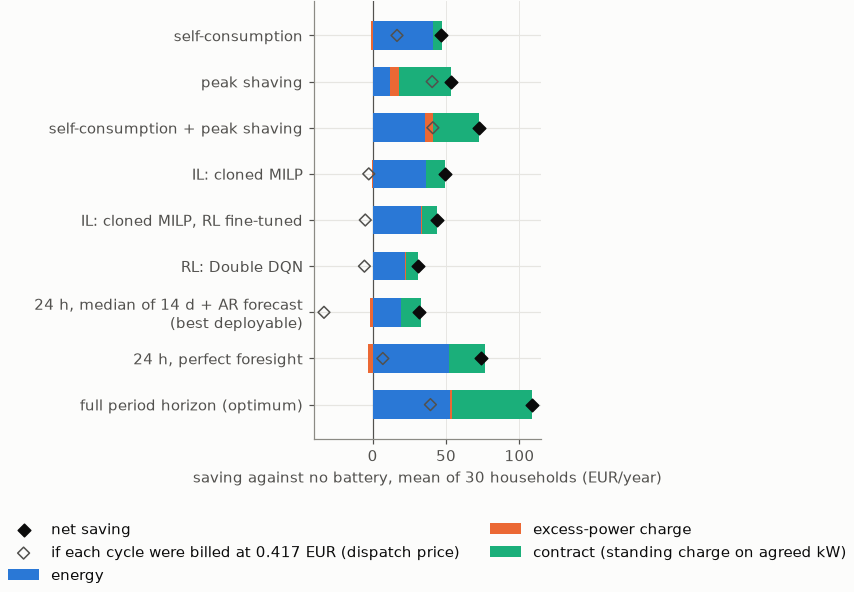

                               energy_closeout  power  contract  wear  wear_shadow    net    efc
controller                                                                                      
self_consumption                          41.3   -0.8       6.3   0.0        -30.2   46.8   72.4
peak_shaving                              11.6    6.1      35.8   0.0        -13.0   53.5   31.1
self_consumption_peak_shaving             35.5    5.4      31.3   0.0        -31.1   72.2   74.7
bc_fc_h24                                 36.5   -0.1      12.8   0.0        -51.9   49.2  124.5
bc_dqn_fc_h24                             33.2    0.3      10.2   0.0        -48.8   43.8  117.1
dqn_fc_h24                                22.2    0.6       8.1   0.0        -36.6   31.0   87.8
mpc_best                                  19.5   -1.5      13.6   0.0        -64.8   31.6  155.4
oracle                                    52.3   -3.4      24.6   0.0        -66.5   73.5  159.7
milp_full                     

In [7]:
# The test year, taken apart. Every bill line as a SAVING against the
# household's own no-battery run; wear is the pack life the cycling uses up
# (zero on every row: no controller ends the pack before 12 y); `net` is the
# study's saving_annual_net. The hollow mark is what `net` WOULD be if every
# cycle were billed at the per-cycle price the MILP and the learned agents
# dispatch against -- the old accounting, drawn for comparison, not charged. The terminal-SOC close-out is cents and rides with energy.
# The MILP family is read off the arm checkpoints, same settlement: the
# full-year optimum and the perfect-foresight MPC from the reference arm, the
# best deployable forecast's MPC from its own arm.
comp, monthly = rb.si_diagnosis_frames({
    "mpc_best": (MPC_BEST_ARM["SI"], "prophet"),
    "oracle": (hs.REFERENCE_ARM["SI"], "oracle"),
    "milp_full": (hs.REFERENCE_ARM["SI"], "milp_full")})
comp["energy_closeout"] = comp.energy + comp.termadj

DIAG_ORDER = ["self_consumption", "peak_shaving", "self_consumption_peak_shaving",
              "bc_fc_h24", "bc_dqn_fc_h24", "dqn_fc_h24",
              "mpc_best", "oracle", "milp_full"]
# `dqn` is not joined onto the study frame (§1), so its label is asked for here.
LABEL.update({c: hs.controller_label(c, 48) for c in DIAG_ORDER if c not in LABEL})
LABEL_SI = labels_for("SI")
# What each bill line MEANS: the study's colour semantics, kept here.
COMPONENTS = [("energy_closeout", "energy", SERIES[0]),
              ("power", "excess-power charge", SERIES[1]),
              ("contract", "contract (standing charge on agreed kW)", SERIES[2]),
              ("wear", "wear", MUTED)]

mean = comp.groupby("controller").mean(numeric_only=True).loc[DIAG_ORDER]
fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.78))
y = np.arange(len(DIAG_ORDER))[::-1]
pos = np.zeros(len(DIAG_ORDER))
neg = np.zeros(len(DIAG_ORDER))
# A line that is zero on every row draws nothing, so it gets no legend entry
# either -- on this sweep that is the wear (no pack is cycled to death early).
for col, lab, color in [x for x in COMPONENTS if mean[x[0]].abs().max() > 1e-9]:
    v = mean[col].to_numpy()
    left = np.where(v >= 0, pos, neg + v)
    ax.barh(y, np.abs(v), left=left, height=0.62, color=color, label=lab, zorder=2)
    pos = np.where(v >= 0, pos + v, pos)
    neg = np.where(v < 0, neg + v, neg)
ax.scatter(mean.net, y, marker="D", s=34, color=INK, zorder=3, label="net saving")
ax.scatter(mean.net + mean.wear_shadow, y, marker="D", s=30, facecolors="none",
           edgecolors=INK_2, linewidths=1.0, zorder=3,
           label=f"if each cycle were billed at "
                 f"{be.cycle_cost_eur_per_efc(10.0):.3f} EUR (dispatch price)")
ax.axvline(0, color=INK_2, lw=0.8, zorder=1)
ax.set_xlim(right=1.06 * max(pos.max(), mean.net.max()))
ax.set_yticks(y)
ax.set_yticklabels([fs.tick_label(c, LABEL_SI) for c in DIAG_ORDER])
ax.grid(axis="x", color=pf.GRID, lw=0.6)
ax.set_axisbelow(True)
pf.key_legend(ax, ax.get_legend_handles_labels()[0], where="below", ncol=2)
finish(ax, title="SI test year: what each controller saves, line by line",
       xlabel=f"saving against no battery, mean of 30 households "
              f"({hs.money('SI', 'year')})", ylabel="", xfmt=PLAIN)
pf.show(fig, "rl_si_bill_lines")

print(mean[["energy_closeout", "power", "contract", "wear", "wear_shadow",
            "net", "efc"]]
      .round(1).to_string())


**The contract is where SI's money is, and the learned controllers do not
collect it.** The full-year MILP earns 54 of its 108 EUR/a on the contract line;
the two shaving rules earn 31–36. The clone collects 13, the fine-tune 10, the
DQN 8. What the learned controllers do earn is energy — the clone 37, close to
self-consumption's 41. Wear is zero for every row: no controller cycles enough
to end the pack before 12 years. The hollow marks show where each row would sit
if every cycle were billed at 0.417 EUR — the old accounting, under which the
clone fell below zero. The
excess-power charge is small for every controller (6 EUR/a at most): the agreed kW
is set from the household's own recent peaks, so there is little excess to
avoid; the saving comes from **lowering the line itself**.

The MILP family is now in the figure too. Beside the full-year MILP are the
24 h MPC with perfect foresight and the 24 h MPC on the best deployable forecast. Both run a 24 h window and so see at most a day of any month's
peak, so neither earns the contract line the way the full-year MILP does: a
receding horizon has the same blind spot as the learners, from a different cause.

The next figure shows that directly: how far each controller moved its own
contract.


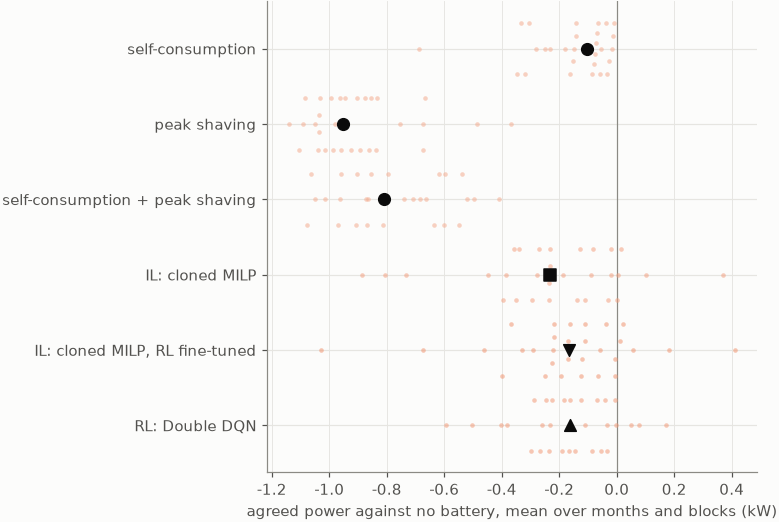

block                             1     2     3     4     5
controller                                                 
self_consumption              -0.12 -0.17 -0.15 -0.14 -0.17
peak_shaving                  -0.96 -0.87 -0.89 -0.91 -0.93
self_consumption_peak_shaving -0.83 -0.77 -0.78 -0.77 -0.77
bc_fc_h24                     -0.41 -0.30 -0.21 -0.18 -0.11
bc_dqn_fc_h24                 -0.31 -0.23 -0.18 -0.13 -0.08
dqn_fc_h24                    -0.23 -0.19 -0.16 -0.15 -0.14


In [8]:
# How far each controller moved its OWN contract: agreed kW against the
# no-battery contract, averaged over the 12 months and five blocks of the test
# year, one dot per household. The contract is re-agreed from the controller's
# realized peaks, so this is the peak shaving the meter actually saw.
shift = (monthly.groupby(["controller", "ident"])["d_agreed_kw"].mean()
         .reset_index())
# The MILP family has no monthly contract in its checkpoints, so only the
# controllers the diagnosis re-ran have a row here.
order = [c for c in DIAG_ORDER if c in set(monthly.controller)][::-1]
fig, ax = plt.subplots(figsize=pf.figsize(ratio=0.70))
for row, c in enumerate(order):
    v = shift.loc[shift.controller == c, "d_agreed_kw"].to_numpy()
    ax.scatter(v, row + fs.beeswarm(v), s=9, alpha=0.55, linewidths=0,
               color=fs.ctrl_color("SI", c), zorder=2)
    ax.scatter([np.median(v)], [row], marker=fs.ctrl_marker(c), s=58,
               color=INK, zorder=3)
ax.axvline(0, color=MUTED, lw=0.8, zorder=1)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([fs.tick_label(c, LABEL) for c in order])
ax.grid(axis="x", color=pf.GRID, lw=0.6)
ax.set_axisbelow(True)
finish(ax, title="SI test year: how far each controller lowered its own contract",
       xlabel="agreed power against no battery, mean over months and blocks (kW)",
       ylabel="", xfmt=pf.KW)
pf.show(fig, "rl_si_contract_shift")

print(monthly.groupby(["controller", "block"])["d_agreed_kw"].mean()
      .unstack().loc[order[::-1]].round(2).to_string())


The shaving rules lower the agreed power by 0.8–1.0 kW in every block; the
learned controllers by 0.08–0.41 kW. (The MILP family has no row here — its monthly
contract is not in the checkpoint, only the bill lines above.)

### Why: the training reward cannot see the contract

The agents are rewarded per interval with the settlement's **variable** part:
energy plus excess-power charge, plus the terminal close-out. Two
things are missing from it, and they are exactly the line above:

1. **The standing charge on the agreed kW.** It is billed, but as `fixed`, and the
   training walk (`rl_control._Walk`) drops it — it looks decision-independent
   per interval and is not, because
2. **the contract never moves during training.** Every training and validation
   rollout is priced against the contract of the *no-battery* household. Only
   the final scoring (`run_policy`) re-agrees the contract from the agent's own
   peaks. So a peak shaved in training is worth only the small excess charge it
   avoids, never the cheaper contract it would buy.

The reward therefore sees about 5 EUR/a of a ~55 EUR/a opportunity. That fits
everything above:

- **The clone keeps some shaving (13 EUR/a contract).** It copies a MILP whose
  objective *does* include the endogenous contract, so it inherits a little of
  it without being rewarded for it.
- **Reinforcement does not add any.** The fine-tune keeps most of what the
  clone had (contract 13 → 10 EUR/a) and plain RL finds 8 on its own: with
  nothing in the reward paying for a lower contract, what shaving they do is a
  side effect of avoiding the excess charge.
- **The validation measure has the same blind spot.** Its rollouts are priced
  against the no-battery contract too, so the SI hyperparameters were chosen on
  a score that cannot see the contract. That choice was made on validation, not
  test, so there is no leak, but it is not SI's whole objective.

More features would not fix this; the agent already sees its block, its agreed
kW, its headroom and its running peak. The reward is what has to change: price
the standing charge on the agreed kW inside the training walk, and let the
contract be re-agreed from the agent's own peaks (month by month in an episode,
or as a shaped credit for lowering next month's line). Validation must use the
same measure. Any such change has to be designed and chosen on the
**validation weeks**; this section only uses the test year to diagnose.


## 7. What this does and does not establish

**Does.** On AU, learned controllers are a genuine alternative to forecast-driven
MPC on the lifetime NPV: the fine-tuned clone at −4206 AUD (253 AUD/a) against
−4843 (181) for the MPC on the best deployable forecast, at one forward pass per
interval instead of an LP solve. On SI the clone beats every deployable MPC and
self-consumption, but not the peak-shaving rules. Every controller in the
comparison — MILP, MPC, learned — now optimises the quantity it is scored on. The learners are trained,
early-stopped and tuned on data that never includes the scored year, and
training convergence is confirmed. Perfect foresight is worth something; no
achievable forecast is.

**Does not.**

1. **The search was narrow.** γ ∈ {0.99, 0.997}, n-step ∈ {1, 8} (RL) and the
   BC regulariser ∈ {0, 1} (IL+RL) were chosen on validation cost (bill plus
   lifetime wear). Only two choices separate: γ 0.997 over 0.99 on AU, and the
   BC regulariser at 1 on both tariffs; the n-step window and SI's γ are ties. `hidden`, `lr`,
   `batch`, `reward_scale` and `episode_days` are defaults. A wider search over
   the validation weeks (`optuna` is already a dependency) is the next step,
   and it has the right split to run on.
2. **SI is not solved, and §6 says why.** The best learner earns 47 EUR/a there,
   against 69 for the rule built for the tariff and 104 for the optimum, which
   earns about half of its saving on the contract. The training reward and the
   validation score price every interval against the *no-battery* contract and
   drop the standing charge on the agreed kW, so the contract, which is most of
   SI's money, is invisible to the learner. The fix is in the reward, not the
   features: price the standing charge and re-agree the contract from the
   agent's own peaks inside training. It has not been run, and it would have to
   be designed and chosen on the validation weeks.
3. **One seed per run.** Run-to-run spread in the earlier budget test reached
   52 EUR on individual households, so per-household numbers are noisy even
   where the paired medians are not.
4. **Four runs did not converge** (§4), all on AU; they are in every figure as they stand.
5. **`truth_h24` is a diagnostic**, like `price_oracle`. It is the ceiling, not
   an option.
